## Taller #5: Introducción a Redes Neuronales


Daniela Solarte &
Andres Herrera

In [1]:
#librerias 
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
#archivo
df = pd.read_csv('auto-mpg.data',
                 names=['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                        'Acceleration', 'Model Year', 'Origin'],
                 sep=' ',
                 na_values='?',
                 comment='\t',
                 skipinitialspace=True)

#elimnar nulos y verificar que este bien
df = df.dropna()
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


1. En un nuevo cuaderno, cree un modelo de redes neuronales que emplee 4 de las
variables/características disponibles en el conjunto de datos para predecir MPG.
Defina una arquitectura inicial con una capa de normalización y una capa oculta
con un número de neuronas de su elección. En su reporte grafique la arquitectura
de la red, incluya el número de parámetros a estimar y justifique este número.

In [3]:
#4 caracteristicas que necesito para predecir MPG 
caracteristicas = ['Horsepower', 'Displacement', 'Weight', 'Acceleration']

#datos entrenamiento y de prueba
train = df.sample(frac=0.8, random_state=100)
test  = df.drop(train.index)

In [4]:
train_X = train[caracteristicas].copy()
test_X  = test[caracteristicas].copy()

train_y = train['MPG'].copy()
test_y  = test['MPG'].copy()


In [5]:
#capa de normalización sobre las 4 caracteristicas que se escogieron
tf.keras.layers.Normalization
norm = tf.keras.layers.Normalization(axis=-1)
norm.adapt(np.array(train_X))

In [6]:
ocultas = 56   #definimos 56 neuronas ocultas
input_layer = tf.keras.layers.Input((4,)) #4 caracteristicas

h_model = tf.keras.Sequential([
    input_layer,   
    norm,                                 #capa normalizacion
    tf.keras.layers.Dense(units=ocultas, activation='relu'),  #capa ocultas
    tf.keras.layers.Dense(units=1)        #capa salida
])

h_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 4)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 56)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346 (1.36 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 9 (40.00 B)

In [7]:
params_oculta  = 4 * ocultas + ocultas        # W + b
params_salida  = ocultas * 1 + 1               # W + b
total          = params_oculta + params_salida

print(f"Parámetros capa oculta : {params_oculta}")
print(f"Parámetros capa salida : {params_salida}")
print(f"Total parámetros       : {total}")

Parámetros capa oculta : 280
Parámetros capa salida : 57
Total parámetros       : 337


2. Entrene este modelo (este es su modelo base), grafique el historial de pérdida de entrenamiento y validación, y comente sus resultados en su reporte.

In [8]:
#compilar
h_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error'   # MAE es común en regresión
)

In [9]:
#entrenar
history = h_model.fit(
    np.array(train_X),
    np.array(train_y),
    epochs=150,
    validation_split=0.2,    #20% de prueba
    verbose=1
)

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 23.7751 - val_loss: 22.1341
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 23.4993 - val_loss: 21.9272
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 23.0230 - val_loss: 21.7177
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 23.4681 - val_loss: 21.5064
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 23.0410 - val_loss: 21.2851
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 23.0252 - val_loss: 21.0593
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.6075 - val_loss: 20.8243
Epoch 8/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.5042 - val_loss: 20.5775
Epoch 9/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 21.9419 - val_loss: 20.3211
Epoch 10/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 22.2050 - val_loss: 20.0557
Epoch 11/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21.4448 - val_loss: 19.7700
Epoch 12/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - lo

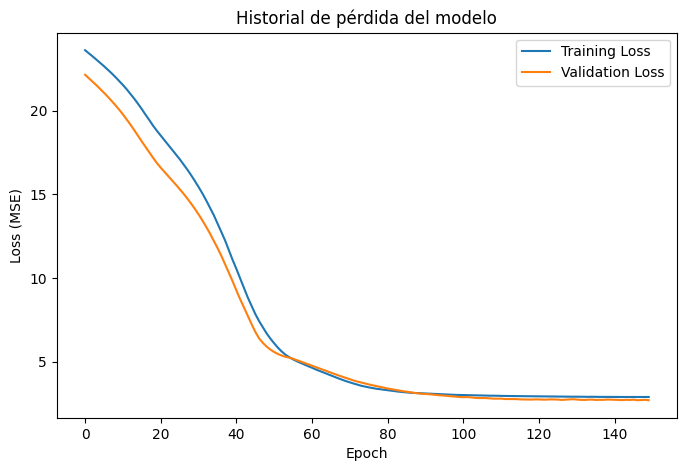

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Historial de pérdida del modelo')

plt.legend()

plt.show()

In [11]:
test_res = {}
test_res['h_model'] = h_model.evaluate(np.array(test_X), np.array(test_y), verbose=0)
test_res

{'h_model': 2.7914836406707764}

3. Modifique el número de neuronas en la capa oculta (3 casos diferentes al modelo base), entrene los modelos resultantes y compare. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su reporte.

In [12]:
###modelo diferente 

def build_model(n_neuronas):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        norm,
        tf.keras.layers.Dense(units=n_neuronas, activation='relu'),
        tf.keras.layers.Dense(units=1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_absolute_error'
    )
    return model

In [13]:
#diferente numero de capas ocultas
modelo_16  = build_model(16)
modelo_128 = build_model(128)
modelo_256 = build_model(256)

history_16 = modelo_16.fit(
    np.array(train_X), np.array(train_y),
    epochs=150, validation_split=0.2, verbose=0
)

history_128 = modelo_128.fit(
    np.array(train_X), np.array(train_y),
    epochs=150, validation_split=0.2, verbose=0
)

history_256 = modelo_256.fit(
    np.array(train_X), np.array(train_y),
    epochs=150, validation_split=0.2, verbose=0
)

print("Entrenamiento completado.")

Entrenamiento completado.


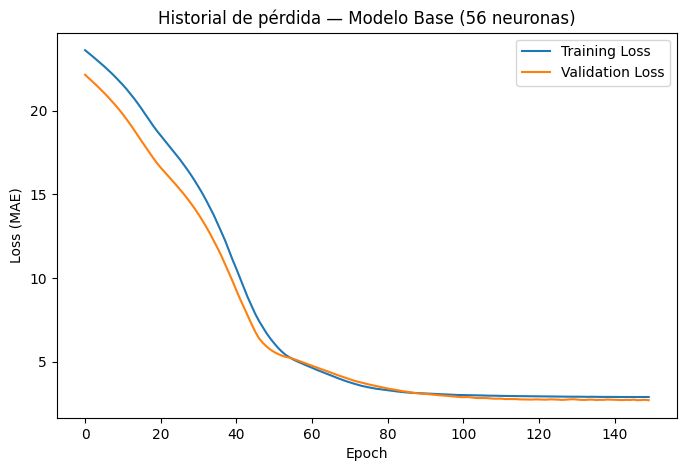

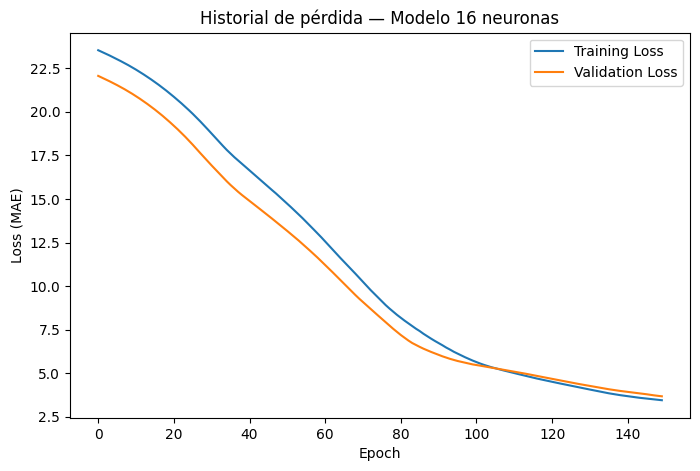

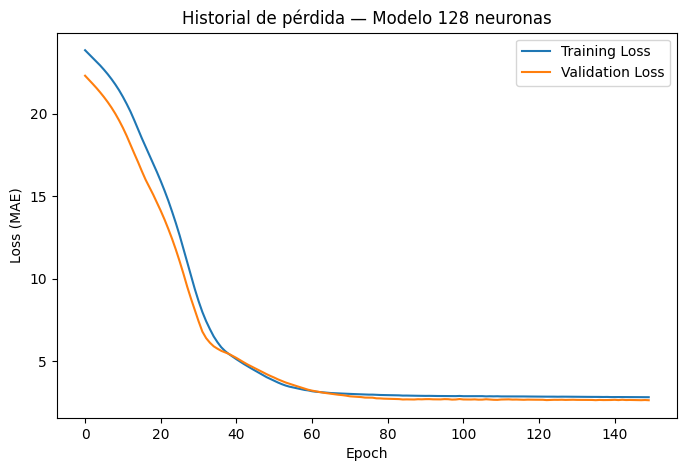

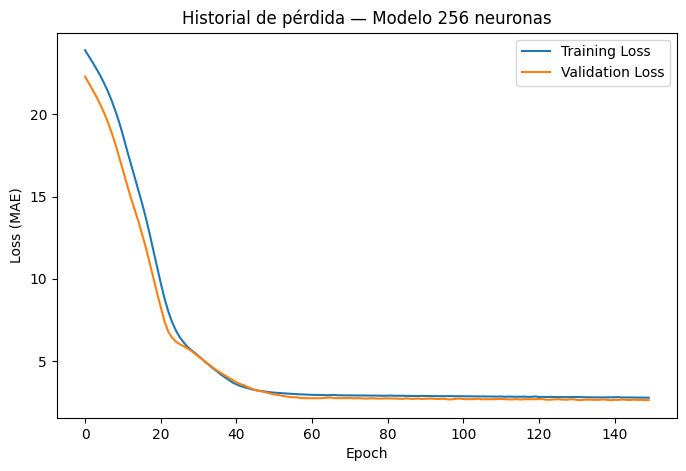

In [14]:
#graficas para comparar
modelos = [
    (history,     f'Modelo Base ({ocultas} neuronas)'),
    (history_16,  'Modelo 16 neuronas'),
    (history_128, 'Modelo 128 neuronas'),
    (history_256, 'Modelo 256 neuronas'),
]

for hist_obj, titulo in modelos:
    plt.figure(figsize=(8, 5))
    plt.plot(hist_obj.history['loss'],     label='Training Loss')
    plt.plot(hist_obj.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MAE)')
    plt.title(f'Historial de pérdida — {titulo}')
    plt.legend()
    plt.show()

In [15]:
#comparando los resultados
test_res['h_model']    = h_model.evaluate(np.array(test_X), np.array(test_y), verbose=0)
test_res['modelo_16']  = modelo_16.evaluate(np.array(test_X), np.array(test_y), verbose=0)
test_res['modelo_128'] = modelo_128.evaluate(np.array(test_X), np.array(test_y), verbose=0)
test_res['modelo_256'] = modelo_256.evaluate(np.array(test_X), np.array(test_y), verbose=0)
test_res

{'h_model': 2.7914836406707764,
 'modelo_16': 3.2447009086608887,
 'modelo_128': 2.7249348163604736,
 'modelo_256': 2.6980035305023193}

4. Modifique el número de capas (3 casos diferentes al modelo base, puede cambiar también el número de neuronas en cada capa), entrene los modelos resultantes y compare. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su reporte. 

In [16]:
def build_model_layers(hidden_layers):
    
    model = tf.keras.Sequential()
    
    model.add(tf.keras.layers.Input(shape=(4,)))
    model.add(norm)  # misma capa de normalización usada antes
    
    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    
    model.add(tf.keras.layers.Dense(1))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_absolute_error'
    )
    
    return model

In [17]:
modelo_capas_1 = build_model_layers([32,16])

history_capas_1 = modelo_capas_1.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_capas_1 = modelo_capas_1.evaluate(test_X, test_y, verbose=0)

resultado_capas_1

2.7088682651519775

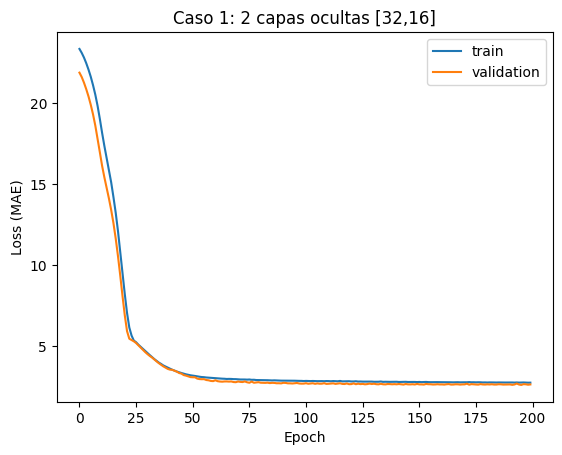

In [18]:
plt.plot(history_capas_1.history['loss'], label='train')
plt.plot(history_capas_1.history['val_loss'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Caso 1: 2 capas ocultas [32,16]')
plt.legend()

plt.show()

In [19]:
modelo_capas_2 = build_model_layers([64,32])

history_capas_2 = modelo_capas_2.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_capas_2 = modelo_capas_2.evaluate(test_X, test_y, verbose=0)

resultado_capas_2

2.732264995574951

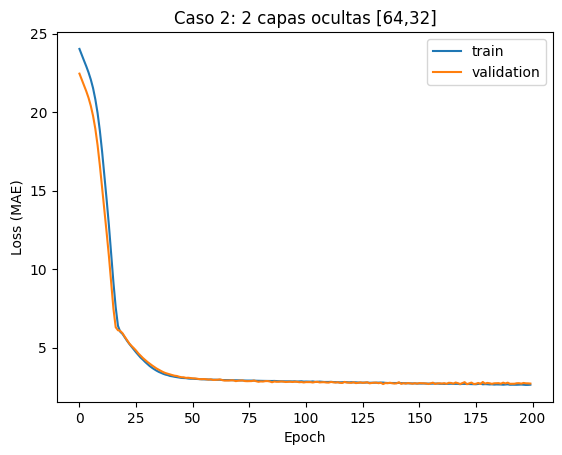

In [20]:
plt.plot(history_capas_2.history['loss'], label='train')
plt.plot(history_capas_2.history['val_loss'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Caso 2: 2 capas ocultas [64,32]')
plt.legend()

plt.show()

In [21]:
modelo_capas_3 = build_model_layers([128,64,32])

history_capas_3 = modelo_capas_3.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_capas_3 = modelo_capas_3.evaluate(test_X, test_y, verbose=0)

resultado_capas_3

2.7515735626220703

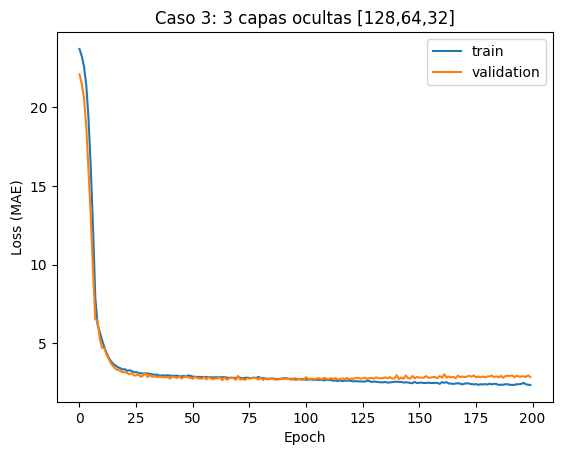

In [22]:
plt.plot(history_capas_3.history['loss'], label='train')
plt.plot(history_capas_3.history['val_loss'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Caso 3: 3 capas ocultas [128,64,32]')
plt.legend()

plt.show()

In [23]:
tabla_capas = pd.DataFrame({
    'Modelo': [
        'Base (56 neuronas)',
        '2 capas [32,16]',
        '2 capas [64,32]',
        '3 capas [128,64,32]'
    ],
    
    'MAE': [
        2.773562,
        resultado_capas_1,
        resultado_capas_2,
        resultado_capas_3
    ]
})

tabla_capas

,Modelo,MAE
0,Base (56 neuronas),2.773562
1,"2 capas [32,16]",2.708868
2,"2 capas [64,32]",2.732265
3,"3 capas [128,64,32]",2.751574


5. Modifique las funciones de activación (3 casos diferentes al modelo base), entrene los modelos resultantes y compare. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su report

In [24]:
def build_model_activation(activation_function):
    
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4,)),
        norm,
        tf.keras.layers.Dense(56, activation=activation_function),
        tf.keras.layers.Dense(1)
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_absolute_error'
    )
    
    return model

In [25]:
modelo_act_1 = build_model_activation('tanh')

history_act_1 = modelo_act_1.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_act_1 = modelo_act_1.evaluate(test_X, test_y, verbose=0)

resultado_act_1

2.801260232925415

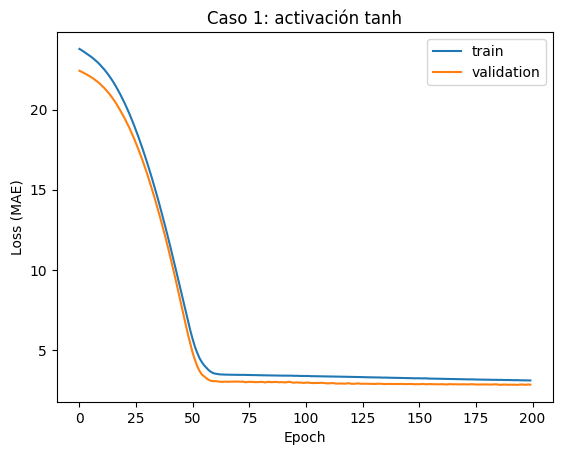

In [26]:
plt.plot(history_act_1.history['loss'], label='train')
plt.plot(history_act_1.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Caso 1: activación tanh')
plt.legend()
plt.show()

In [27]:
modelo_act_2 = build_model_activation('sigmoid')

history_act_2 = modelo_act_2.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_act_2 = modelo_act_2.evaluate(test_X, test_y, verbose=0)

resultado_act_2

2.888141393661499

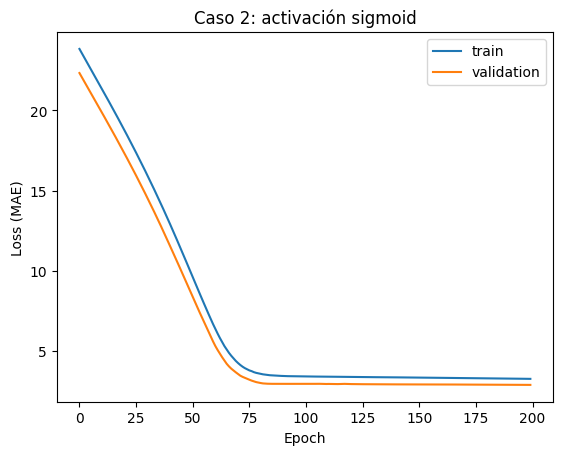

In [28]:
plt.plot(history_act_2.history['loss'], label='train')
plt.plot(history_act_2.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Caso 2: activación sigmoid')
plt.legend()
plt.show()

In [29]:
modelo_act_3 = build_model_activation('elu')

history_act_3 = modelo_act_3.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_act_3 = modelo_act_3.evaluate(test_X, test_y, verbose=0)

resultado_act_3

2.755347490310669

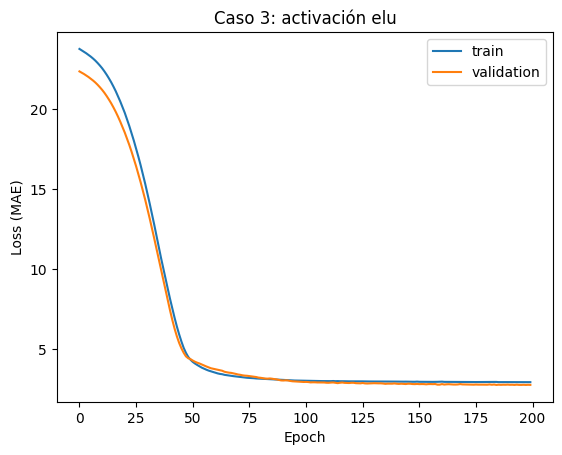

In [30]:
plt.plot(history_act_3.history['loss'], label='train')
plt.plot(history_act_3.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Caso 3: activación elu')
plt.legend()
plt.show()

In [31]:
tabla_activaciones = pd.DataFrame({
    'Modelo': [
        'Base (relu)',
        'Activación tanh',
        'Activación sigmoid',
        'Activación elu'
    ],
    'MAE': [
        2.773562,
        resultado_act_1,
        resultado_act_2,
        resultado_act_3
    ]
})

tabla_activaciones

,Modelo,MAE
0,Base (relu),2.773562
1,Activación tanh,2.801260
2,Activación sigmoid,2.888141
3,Activación elu,2.755347


A partir de los resultados anteriores proponga y evalué 2 modelos diferentes al modelo base y compárelos. Use siempre los mismos datos de entrenamiento y prueba. Comente sus resultados en su reporte. 

In [32]:
def build_model_propuesta(hidden_layers, activation_function):
    
    model = tf.keras.Sequential()
    
    model.add(tf.keras.layers.Input(shape=(4,)))
    model.add(norm)
    
    for units in hidden_layers:
        model.add(tf.keras.layers.Dense(units, activation=activation_function))
        
    model.add(tf.keras.layers.Dense(1))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mean_absolute_error'
    )
    
    return model

In [33]:
modelo_propuesto_1 = build_model_propuesta([32,16], 'elu')

history_prop_1 = modelo_propuesto_1.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_prop_1 = modelo_propuesto_1.evaluate(test_X, test_y, verbose=0)

resultado_prop_1

2.6331825256347656

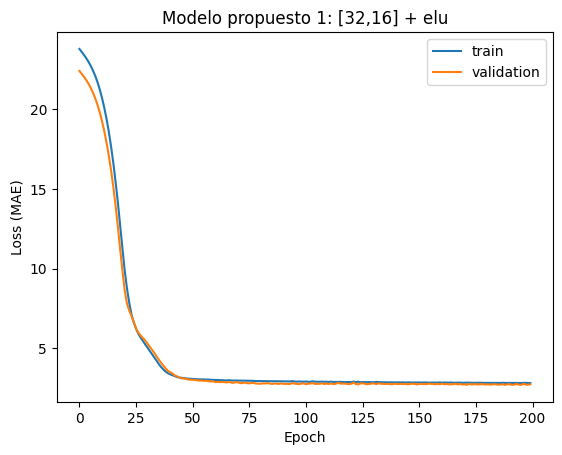

In [34]:
plt.plot(history_prop_1.history['loss'], label='train')
plt.plot(history_prop_1.history['val_loss'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Modelo propuesto 1: [32,16] + elu')

plt.legend()
plt.show()

In [35]:
modelo_propuesto_2 = build_model_propuesta([64,32], 'elu')

history_prop_2 = modelo_propuesto_2.fit(
    train_X,
    train_y,
    validation_split=0.2,
    epochs=200,
    verbose=0
)

resultado_prop_2 = modelo_propuesto_2.evaluate(test_X, test_y, verbose=0)

resultado_prop_2

2.696702241897583

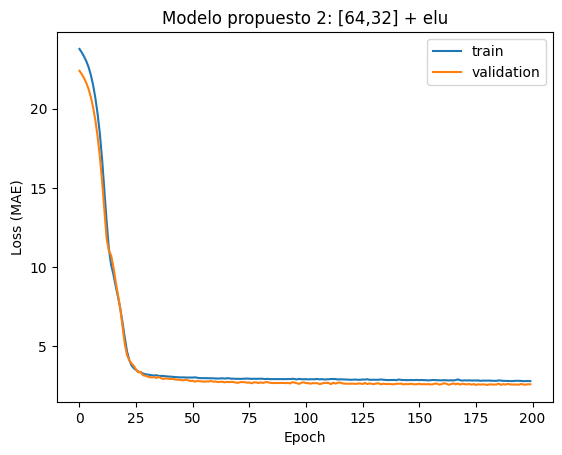

In [36]:
plt.plot(history_prop_2.history['loss'], label='train')
plt.plot(history_prop_2.history['val_loss'], label='validation')

plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Modelo propuesto 2: [64,32] + elu')

plt.legend()
plt.show()

In [37]:
tabla_modelos_finales = pd.DataFrame({
    'Modelo': [
        'Base (56 relu)',
        'Propuesto 1 [32,16] elu',
        'Propuesto 2 [64,32] elu'
    ],
    
    'MAE': [
        2.773562,
        resultado_prop_1,
        resultado_prop_2
    ]
})

tabla_modelos_finales

,Modelo,MAE
0,Base (56 relu),2.773562
1,"Propuesto 1 [32,16] elu",2.633183
2,"Propuesto 2 [64,32] elu",2.696702
